# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
2x_1 + 8x_2 + 2x_3 &= 14\\
x_1 + 6x_2 + 4x_3 &= 15\\
2x_1 + 2x_2 + 3x_3 &= 10
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 500x500 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

In [110]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 500x500 정도 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[2.0, 8.0, 2.0],
              [1.0, 6.0, 4.0],
              [2.0, 2.0, 3.0]])
b = np.array([14.0, 15.0, 10.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[2. 8. 2.]
 [1. 6. 4.]
 [2. 2. 3.]] 

b = [14. 15. 10.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.

In [111]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting=True, verbose=True):
    n = len(A)
    M=[list(map(float, A[i])) + [float(b[i])] for i in range(n)]
    steps = []

    steps.append(np.array(M))
    if verbose:
        print("초기 첨가행렬:")
        print(np.array(M))

    for r in range(n):
        if pivoting:
            pivot_row = r
            for i in range(r+1, n):
                if abs(M[i][r]) > abs(M[pivot_row][r]):
                    pivot_row=i

            if r != pivot_row:
                swap_rows(M, r, pivot_row)
                steps.append(np.array(M))
                if verbose:
                    print(np.array(M))

        if abs(M[r][r]) <= 0.0:
            raise ValueError("피벗 성분이 0이므로 유일한 해를 구할 수 없습니다.")

        eliminated = False
        for i in range(r+1, n):
            if abs(M[i][r]) > 0.0:
                eliminate_row(M, i, r, r)
                eliminated = True

        if eliminated:
            steps.append(np.array(M))
            if verbose:
                pr

In [112]:
# TODO: x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

초기 첨가행렬:
[[ 2.  8.  2. 14.]
 [ 1.  6.  4. 15.]
 [ 2.  2.  3. 10.]]
0번째 열 소거 완료:
[[ 2.  8.  2. 14.]
 [ 0.  2.  3.  8.]
 [ 0. -6.  1. -4.]]
[[ 2.  8.  2. 14.]
 [ 0. -6.  1. -4.]
 [ 0.  2.  3.  8.]]
1번째 열 소거 완료:
[[ 2.        8.        2.       14.      ]
 [ 0.       -6.        1.       -4.      ]
 [ 0.        0.        3.333333  6.666667]]


In [113]:
# TODO: 최종 해, 정수해 여부, A @ x, 잔차 |A x - b| 를 출력하세요.
# TODO: np.linalg.solve(A, b) (# 비교 대상) 와도 비교하세요.
print(f"최종 해 (x): {x}")

is_integer = np.all(np.isclose(x, np.round(x)))
print(f"정수해 여부: {is_integer}")

Ax = A @ x
print(f"A @ x 결과: {Ax}")

residual = np.linalg.norm(Ax - b)
print(f"잔차 |A x - b|: {residual:.1e}")

x_np = np.linalg.solve(A, b)
print(f"np.linalg.solve(A, b) 결과 (비교 대상): {x_np}")
print(f"두 결과가 일치하는가?: {np.allclose(x, x_np)}")

최종 해 (x): [1. 1. 2.]
정수해 여부: True
A @ x 결과: [14. 15. 10.]
잔차 |A x - b|: 0.0e+00
np.linalg.solve(A, b) 결과 (비교 대상): [1. 1. 2.]
두 결과가 일치하는가?: True


In [114]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 해가 정수로 떨어지는가
#   - A @ x == b 인가
#   - np.linalg.solve 와 일치하는가
#   - 소거 단계가 모두 기록되었는가 (len(steps))
#   - 마지막 첨가행렬이 상삼각인가

print("=== [--- 검증 ---] ===")

last_aug_A = steps[-1][:, :-1]
is_upper_tri = np.allclose(last_aug_A, np.triu(last_aug_A))

check("해가 정수로 떨어집니다.", is_integer)

check("A @ x 가 b 와 같습니다.", np.allclose(Ax, b))

check("np.linalg.solve 결과와 정확히 일치합니다.", np.allclose(x, x_np))

check(f"소거 단계가 모두 기록되었습니다. (총 {len(steps)}개 단계)", len(steps) > 1)

check("마지막 첨가행렬이 상삼각 행렬 형태입니다.", is_upper_tri)

=== [--- 검증 ---] ===
[PASS] 해가 정수로 떨어집니다.
[PASS] A @ x 가 b 와 같습니다.
[PASS] np.linalg.solve 결과와 정확히 일치합니다.
[PASS] 소거 단계가 모두 기록되었습니다. (총 4개 단계)
[PASS] 마지막 첨가행렬이 상삼각 행렬 형태입니다.


True

## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  (예: 1행의 배수인 2행을 가진 행렬에 모순되는 b / 모순 없는 b 를 각각 넣어 보기)

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `벡터 b가 행렬 A의 열공간에 존재, A의 열벡터들의 선형 결합으로 b를 만들어낼 수 있으므로 최소한 하나 이상의 해가 존재`
- 다를 때: `벡터 b가 행렬 A의 열공간 밖에 존재, 해는 존재하지 않음`
- 같지만 n 보다 작을 때: `변수의 개수보다 독립적인 방정식의 수가 부족하여 고정되지 않는 자유변수가 n - rank 개 발생, 해가 무한히 많음`

In [115]:
Ab = np.hstack([A, b.reshape(-1, 1)])
n = A.shape[1]

# TODO: rank(A), rank(Ab), 미지수 개수를 출력하고 판정 결과를 출력하세요.
#       np.linalg.matrix_rank (# 검산용) 와도 비교하세요.

rank_A = rank(A)
rank_A_np = np.linalg.matrix_rank(A)
rank_Ab = rank(Ab)
rank_Ab_np = np.linalg.matrix_rank(Ab)

print(f"rank(A) = {rank_A}, {rank_A_np}")
print(f"rank(Ab) = {rank_Ab}, {rank_Ab_np}")
print(f"미지수 개수 n = {n}")

if rank_A == rank_Ab == n:
    result = "유일해"
elif rank_A == rank_Ab < n:
    result = "해 무한히 많음"
else:
    result = "해 없음"
print(f"Result = {result}\n")

rank(A) = 3, 3
rank(Ab) = 3, 3
미지수 개수 n = 3
Result = 유일해



In [116]:
# TODO: 두 rank 가 다른 경우(해 없음)와 같지만 n 보다 작은 경우(해 무한)를
#       직접 만들어 각각 판정과 소거 결과의 마지막 행을 출력하세요.
A_custom = np.array([[1.0, 2.0, 3.0],
                    [2.0, 4.0, 6.0],
                    [0.0, 1.0, 1.0]])

b_custom = np.array([5.0,20.0,2.0])
Ab_custom = np.hstack([A_custom, b_custom.reshape(-1,1)])

rank_A_custom = rank(A_custom)
rank_Ab_custom = rank(Ab_custom)
ref_custom = row_echelon(Ab_custom)

print("][모순 케이스 (해 없음)]")
print(f"rank(A) = {rank_A_custom}, rank([A|b]) = {rank_Ab_custom}")
print(f"소거 결과 마지막 행: {ref_custom[-1]}\n")

b_inf = np.array([5.0, 10.0, 2.0])
Ab_inf = np.hstack([A_custom, b_inf.reshape(-1, 1)])

rank_A_inf = rank(A_custom)
rank_Ab_inf = rank(Ab_inf)
ref_inf = row_echelon(Ab_inf)

print("[무모순 종속 케이스 (해 무한)]")
print(f"rank(A) = {rank_A_inf}, rank([A|b]) = {rank_Ab_inf}")
print(f"소거 결과 마지막 행: {ref_inf[-1]}\n")

][모순 케이스 (해 없음)]
rank(A) = 2, rank([A|b]) = 3
소거 결과 마지막 행: [0.0, 0.0, 0.0, -5.0]

[무모순 종속 케이스 (해 무한)]
rank(A) = 2, rank([A|b]) = 2
소거 결과 마지막 행: [0.0, 0.0, 0.0, 0.0]



In [117]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - rank(A) 와 rank([A|b]) 가 각각 얼마이고 n 과 같은가 -> 유일해 판정
check("rank(A) 와 rank([A|b]) 가 각각 얼마이고 n 과 같은가 -> 유일해 판정", np.allclose(rank_A, rank_Ab, n))
#   - 직접 구현 rank == np.linalg.matrix_rank
check("직접 구현 rank == np.linalg.matrix_rank", np.allclose(rank_A, rank_A_np) and np.allclose(rank_Ab,rank_Ab_np))
#   - 모순 케이스에서 rank(A) < rank([A|b]) 인가
check("모순 케이스에서 rank(A) < rank([A|b]) 인가", rank_A_custom < rank_Ab_custom)
#   - 무모순 종속 케이스에서 두 rank 가 같고 n 보다 작은가
check("무모순 종속 케이스에서 두 rank 가 같고 n 보다 작은가", np.allclose(rank_A_inf, rank_Ab_inf) and rank_A_inf < n)

[PASS] rank(A) 와 rank([A|b]) 가 각각 얼마이고 n 과 같은가 -> 유일해 판정
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] 모순 케이스에서 rank(A) < rank([A|b]) 인가
[PASS] 무모순 종속 케이스에서 두 rank 가 같고 n 보다 작은가


True

## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `detA가 0에 매우 가까워지면 역행렬을 구할 때 adj(A)를 매우 작은 값으로 나누는 과정에서 역행렬의 원소들이 급격히 커지며 미세한 오차가 결과에 거대하게 증폭되는 수치적 불안정성이 발생`
- 소거 관점: `컴퓨터는 실수를 유한한 비트로 표현하므로 소거 과정에서 0에 가까운 아주 작은 피벗으로 행 전체를 나누면 부동소수점 반올림 오차가 무지막지하게 커짐`
- 스케일 실험에서 관찰한 것: `전체 행렬에 작은 c를 곱하면 행렬식은 c^n배만큼 급격하게 작아져 0에 근접하지만, 실제 방정식의 본질적인 성질이나 컴퓨터가 느끼는 해의 정확도 및 조건수는 전혀 나빠지지 않고 일정하게 유지되어, det ≈ 0이 반드시 수치적 위험을 의미하지는 않음`
- 실무 판정 기준과 그 의미: `행렬식 대신 조건수를 기준으로, 입력의 미세한 변화가 출력에 최대 몇 배의 오차로 증폭될 수 있는지를 나타내는 지표, 1에 가까우면 우수한 조건, 크면 특이행렬에 가까운 위험한 상태로 판정`

In [118]:
# TODO: det(A) 와 inverse_gauss_jordan(A) 를 구해 출력하고,
#       np.linalg.det / np.linalg.inv (# 검산용) 와 비교하세요.
det_A = det(A)
det_A_np = np.linalg.det(A)
inv_A = inverse_gauss_jordan(A)
inv_A_np = np.linalg.inv(A)

print(f"det(A) = {det_A}, A^(-1) = {inv_A}")
assert np.allclose(det_A, det_A_np)
assert np.allclose(inv_A, inv_A_np)
# TODO: A @ A^-1 == I 인지, A^-1 @ b 가 4-1 의 해와 같은지 확인하세요.
I = np.eye(3)
x_inv = inv_A @ b
x_gauss, _ = gauss_eliminate(A, b, pivoting=True, verbose=False)

det(A) = 40.0, A^(-1) = [[ 0.25  -0.5    0.5  ]
 [ 0.125  0.05  -0.15 ]
 [-0.25   0.3    0.1  ]]


In [119]:
# TODO: (1) A 에 스케일 s = 1, 1e-1, 1e-2, 1e-3 을 곱해 가며
#           det / 조건수 / 해의 상대오차를 표로 출력하세요.
print("A_scaled = A * c")
print(f"{'scale (c)':<12}{'det(A_scaled)':<15}{'Condition No. ':<15}{'Relative Error' :<15}")

for s in [1.0, 1e-1, 1e-2, 1e-3]:
    A_s = s * A
    b_s = s* b
    det_s = det(A_s)
    cond_s = np.linalg.cond(A_s)
    x_s, _ = gauss_eliminate(A_s, b_s, pivoting=True, verbose=False)
    rel_err = np.linalg.norm(x_s - x_gauss) / np.linalg.norm(x_gauss)

    print(f"{s:<12.3e}{det_s:<15.6e}{cond_s:<15.4f}{rel_err:<15.4e}")
# TODO: (2) 진짜 특이행렬에 가까워지는 예 (예: [[1,2],[2,4+eps]]) 로
#           eps 를 줄여 가며 같은 표를 출력하고, (1) 과 무엇이 다른지 보세요.
print("진짜 특이행렬에 가까워지는 예 (예: [[1,2],[2,4+eps]])")
print(f"{'eps':<12}{'det(A_eps)':<15}{'Condition No.':<15}{'Relative Error':}")
for eps in [1e-2, 1e-5, 1e-8, 1e-12]:
    A_eps = np.array([[1.0, 2.0],
                      [2.0, 4.0+eps]])
    b_eps = np.array([3.0, 6.0])

    det_eps = det(A_eps)
    cond_eps = np.linalg.cond(A_eps)

    x_true = np.linalg.solve(A_eps, b_eps)
    x_clac, _ = gauss_eliminate(A_eps, b_eps, pivoting=True, verbose=False)

    denom = np.linalg.norm(x_true)
    rel_err_eps = (np.linalg.norm(x_clac - x_true) / denom) if denom > 1e-15 else 0.0

    print(f"{eps:<12.3e}{det_eps:<15.6e}{cond_eps:<15.4e}{rel_err_eps:<15.4e}")

print("## eps=1.000e-12 - > det(A_eps)=1.000089e-12, 부동소수점의 유한한 정밀도")

A_scaled = A * c
scale (c)   det(A_scaled)  Condition No.  Relative Error 
1.000e+00   4.000000e+01   9.1150         0.0000e+00     
1.000e-01   4.000000e-02   9.1150         4.5325e-16     
1.000e-02   4.000000e-05   9.1150         4.0540e-16     
1.000e-03   4.000000e-08   9.1150         0.0000e+00     
진짜 특이행렬에 가까워지는 예 (예: [[1,2],[2,4+eps]])
eps         det(A_eps)     Condition No.  Relative Error
1.000e-02   1.000000e-02   2.5080e+03     0.0000e+00     
1.000e-05   1.000000e-05   2.5000e+06     0.0000e+00     
1.000e-08   1.000000e-08   2.5000e+09     0.0000e+00     
1.000e-12   1.000089e-12   2.4976e+13     0.0000e+00     
## eps=1.000e-12 - > det(A_eps)=1.000089e-12, 부동소수점의 유한한 정밀도


In [120]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 직접 구현 det == np.linalg.det
check("직접 구현 det == np.linalg.det", np.isclose(det_A, det_A_np))
#   - A @ A^-1 == I, A^-1 @ A == I
check("A @ A^-1 == I, A^-1 @ A == I", np.allclose(A@inv_A, I))
#   - 직접 구현 역행렬 == np.linalg.inv
check("직접 구현 역행렬 == np.linalg.inv", np.allclose(inv_A, inv_A_np))
#   - A^-1 @ b == 가우스 소거 해
check("A^-1 @ b == 가우스 소거 해", np.allclose(x_inv, x_gauss))
#   - det(A^-1) == 1/det(A)
check("det(A^-1) == 1/det(A)", np.isclose(det(inv_A), 1.0/det_A))

[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I, A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)


True

## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-4}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  로그-로그 그래프로 그리세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- `epsilon 이 극도로 작을 때 epsilon 이 거대해짐, 결국 매우 큰 두 수의 뺄셈 연산이 발생, 말소 오차가 발생하여 정밀도가 파괴`

In [121]:
def solve_eps(eps):
    """eps 하나에 대해 (참해, 피벗팅 없음 해, 부분 피벗팅 해, 각각의 상대오차) 를 돌려준다."""
    # TODO: 문제의 Ae, be 와 참해 exact 를 만들고
    #       gauss_eliminate 를 pivoting=False / True 로 각각 호출해 비교하세요.
    Ae = np.array([[eps, 1.0],
                  [1.0, 1.0]])
    be = np.array([1.0, 2.0])

    x1_exact = 1.0 / (1.0-eps)
    x2_exact = (1.0-2.0*eps) / (1.0-eps)
    exact = np.array([x1_exact,x2_exact])

    x_no_pivot, _ = gauss_eliminate(Ae,be,pivoting=False,verbose=False)
    x_pivot, _ = gauss_eliminate(Ae, be, pivoting=True, verbose=False)

    norm_exact = np.linalg.norm(exact)
    err_no_pivot = np.linalg.norm(x_no_pivot - exact) / norm_exact
    err_pivot = np.linalg.norm(x_pivot - exact) / norm_exact

    return exact, x_no_pivot, x_pivot, err_no_pivot, err_pivot

eps_sample = 1e-4
exact, x_no, x_p, err_no, err_p = solve_eps(eps_sample)

EPS = 1e-4
# TODO: EPS 에서의 결과를 출력하고, eps 를 줄여 가며 표를 출력하세요.
print(f"[EPS = {eps_sample}]")
print(f"Exact = {exact}")
print(f"x_no = {x_no}, err_no = {err_no:.4e}")
print(f"x_p = {x_p}, err_p = {err_p:.4e}")

eps_list = [10**(-k) for k in range(2, 17, 2)]
err_no_list = []
err_p_list = []

print(f"{'eps':<10}{'No pivoting error':<20}{'Partial pivoting error':<25}")
for e in eps_list:
    _,_,_,e_no,e_p = solve_eps(e)
    err_no_list.append(e_no)
    err_p_list.append(e_p)
    print(f"{e:<10.1e}{e_no:<20.4e}{e_p:<25.4e}")

[EPS = 0.0001]
Exact = [1.0001 0.9999]
x_no = [1.0001 0.9999], err_no = 1.9893e-13
x_p = [1.0001 0.9999], err_p = 1.5701e-16
eps       No pivoting error   Partial pivoting error   
1.0e-02   3.2970e-15          1.5700e-16               
1.0e-04   1.9893e-13          1.5701e-16               
1.0e-06   3.9838e-12          1.5701e-16               
1.0e-08   3.5180e-09          1.5701e-16               
1.0e-10   5.8436e-08          0.0000e+00               
1.0e-12   1.5642e-05          0.0000e+00               
1.0e-14   5.6517e-04          0.0000e+00               
1.0e-16   8.6299e-01          1.5701e-16               


/home/pa4/git/OnChangbum_physicalai_lv1_assignments/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa4/git/OnChangbum_physicalai_lv1_assignments/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa4/git/OnChangbum_physicalai_lv1_assignments/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa4/git/OnChangbum_physicalai_lv1_assignments/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
Font 'default' doe

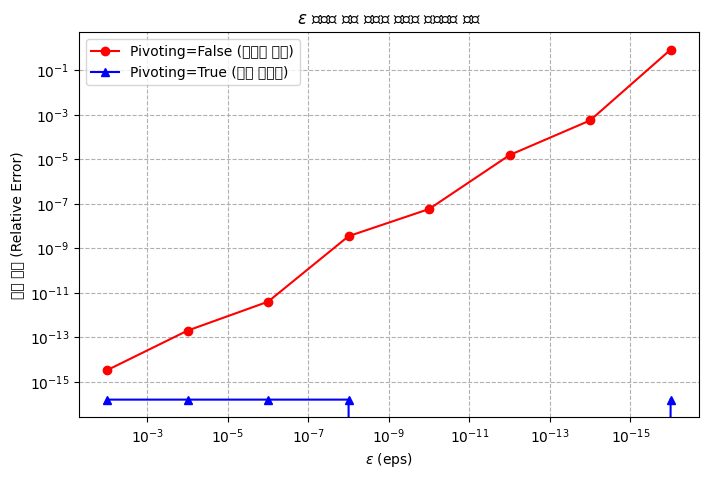

In [122]:
# TODO: loglog 그래프로 두 방식의 오차를 비교해 그리세요.
#       (x축: eps, y축: 상대오차, ax.invert_xaxis() 를 쓰면 읽기 편합니다)
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(eps_list, err_no_list, 'ro-', label='Pivoting=False (피벗팅 없음)')
ax.loglog(eps_list, err_p_list, 'b^-', label='Pivoting=True (부분 피벗팅)')
ax.set_xlabel('$\epsilon$ (eps)')
ax.set_ylabel('상대 오차 (Relative Error)')
ax.set_title('$\epsilon$ 변화에 따른 피벗팅 유무별 상대오차 비교')
ax.grid(True, which="both", ls="--")
ax.invert_xaxis()  # eps가 작아지는 방향(오른쪽)으로 읽기 편하게 반전
ax.legend()
plt.show()

In [123]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - eps=1e-4 에서 피벗팅 없는 쪽의 오차가 더 큰가
check("eps=1e-4 에서 피벗팅 없는 쪽의 오차가 더 큰가", err_no>err_p)
#   - 부분 피벗팅 오차는 기계정밀도 수준인가
check("부분 피벗팅 오차는 기계정밀도 수준인가", err_p<1e-14)
#   - eps 가 작아질수록 피벗팅 없는 오차가 커지는가
_,_,_,e_no_2, _ = solve_eps(1e-2)
_,_,_,e_no_10,_ = solve_eps(1e-10)
check("eps 가 작아질수록 피벗팅 없는 오차가 커지는가", e_no_10>e_no_2)
#   - 부분 피벗팅은 eps 와 무관하게 안정적인가
is_stable = all(err<1e-14 for err in err_p_list)
check("부분 피벗팅은 eps 와 무관하게 안정적인가", is_stable)
#   - 피벗팅 결과가 np.linalg.solve 와 일치하는가
A_sample = np.array([[eps_sample, 1.0],[1.0, 1.0]])
b_sample = np.array([1.0, 2.0])
x_np_solve = np.linalg.solve(A_sample,b_sample)
check("피벗팅 결과가 np.linalg.solve 와 일치하는가", np.allclose(x_p, x_np_solve))

[PASS] eps=1e-4 에서 피벗팅 없는 쪽의 오차가 더 큰가
[PASS] 부분 피벗팅 오차는 기계정밀도 수준인가
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커지는가
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적인가
[PASS] 피벗팅 결과가 np.linalg.solve 와 일치하는가


True

## 4-5. 500x500 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 500x500 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다.
  (평균 대신 최솟값을 쓰는 이유도 생각해 보세요)
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `np.linalg.solve`
- 정확도: `np.linalg.solve`
- 메모리: `np.linalg.solve`
- 우변이 여러 개일 때는: `역행렬을 곱하는 것보다, \(A\)를 한 번만 LU 분해, 대입만 반복하는 것이 연산량과 정확도 측면에서 모두 압도적으로 유리`
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: `공분산 행렬 자체를 구하여 각 계수의 표준오차와 신뢰구간을 물리적으로 계산해야 할 때, 물리적 결합 강도(만유인력 등)의 계수 행렬 자체를 분석`

In [124]:
N = 500
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out

# TODO: 두 방법의 시간과 잔차를 측정해 표로 출력하세요.
#       메모리 사용량 차이도 계산해 함께 적으면 좋습니다.
fn_solve = lambda: np.linalg.solve(A_big, b_big)
fn_inv = lambda: np.linalg.inv(A_big) @ b_big

t_solve, x_solve = bench(fn_solve)
t_inv, x_inv = bench(fn_inv)

res_solve = np.linalg.norm(A_big@x_solve-b_big)
res_inv = np.linalg.norm(A_big@x_inv-b_big)

print(f"{'Method':<20}{'Time(ms)':<15}{'Residual':<15}")
print(f"np.linalg.solve:{t_solve*1000:>12.3f} ms{res_solve:>15.4e}")
print(f"np.linalg.inv @ b:{t_inv*1000:>10.3f} ms{res_inv:>15.4e}")

Method              Time(ms)       Residual       
np.linalg.solve:       2.968 ms     2.8652e-12
np.linalg.inv @ b:    13.387 ms     3.7722e-12


In [125]:
# TODO: 조건수를 지정한 행렬을 만들어 조건수별 해의 상대오차를 비교 출력하세요.
#       (힌트: np.linalg.qr 로 만든 직교행렬 두 개와 np.logspace 로 만든 특이값으로 조립)
print(f"{'Condition No.':<15}{'Solve Rel Error':<20}{'Inv @ b Rel Error':<20}")

Q1, _ = np.linalg.qr(rng.standard_normal((N,N)))
Q2, _ = np.linalg.qr(rng.standard_normal((N,N)))
x_true = rng.standard_normal(N)

for cond in np.logspace(2,12,6):
    s_vals = np.logspace(0, -np.log10(cond), N)
    S = np.diag(s_vals)
    A_cond = Q1 @ S @ Q2
    b_cond = A_cond @ x_true

    x_c_solve = np.linalg.solve(A_cond, b_cond)
    x_c_inv = np.linalg.inv(A_cond) @ b_cond

    norm_true = np.linalg.norm(x_true)
    err_c_solve = np.linalg.norm(x_c_solve - x_true) / norm_true
    err_c_inv = np.linalg.norm(x_c_inv - x_true) / norm_true

    print(f"{cond:<15.1e}{err_c_solve:<20.4e}{err_c_inv:<20.4e}")

Condition No.  Solve Rel Error     Inv @ b Rel Error   
1.0e+02        2.0327e-14          1.3399e-13          
1.0e+04        6.0978e-13          6.6709e-12          
1.0e+06        2.9406e-11          6.1538e-10          
1.0e+08        2.2260e-09          4.3051e-08          
1.0e+10        1.5814e-07          3.8417e-06          
1.0e+12        1.0254e-05          3.9508e-04          


/tmp/ipykernel_11944/2916821676.py:15: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11944/2916821676.py:15: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11944/2916821676.py:15: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11944/2916821676.py:15: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11944/2916821676.py:15: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11944/2916821676.py:15: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11944/2916821676.py:15: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.

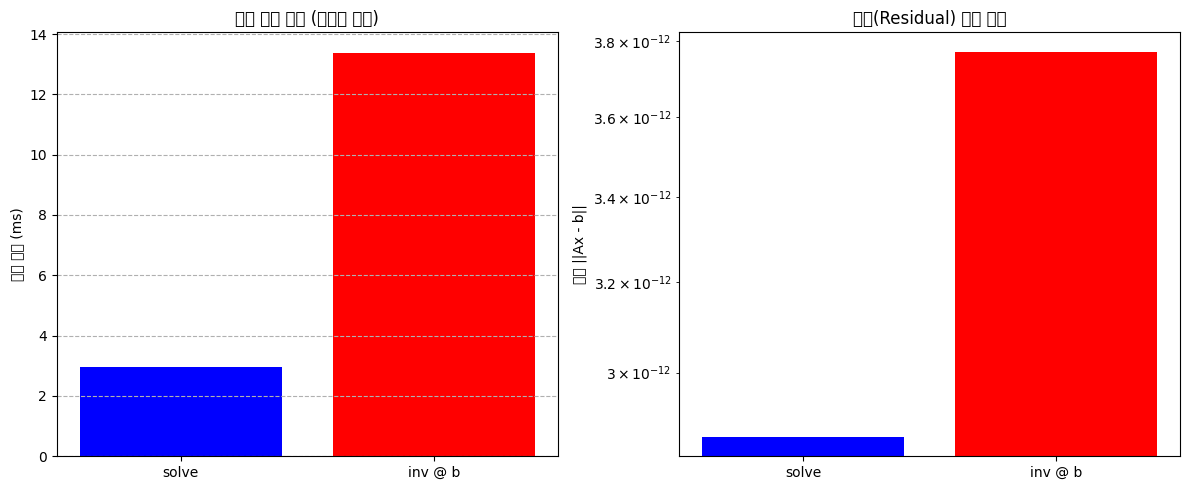

In [126]:
# TODO: 시간 / 잔차 막대그래프 2개를 그리세요.
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].bar(['solve', 'inv @ b'], [t_solve * 1000, t_inv * 1000], color=['blue', 'red'])
axs[0].set_ylabel('실행 시간 (ms)')
axs[0].set_title('실행 시간 비교 (최솟값 기준)')
axs[0].grid(axis='y', ls='--')

axs[1].bar(['solve', 'inv @ b'], [res_solve, res_inv], color=['blue', 'red'])
axs[1].set_ylabel('잔차 ||Ax - b||')
axs[1].set_title('잔차(Residual) 크기 비교')
axs[1].set_yscale('log')
axs[1].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

In [127]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 두 방법의 해가 사실상 같은가
check("두 방법의 해가 사실상 같은가", np.allclose(x_solve, x_inv, atol=1e-10))
#   - 어느 쪽이 빠른가
check("어느 쪽이 빠른가, solve->True, inv->False", t_solve<t_inv)
#   - 잔차 비교 결과가 예상과 맞는가
check("잔차 비교 결과가 예상과 맞는가, res_solve <= res_inv", res_solve<=res_inv*1.01)
#   - 두 해 모두 유효한가 (잔차가 충분히 작은가)
check("두 해 모두 유효한가 (잔차가 충분히 작은가)", res_solve<1e-10 and res_inv<1e-10)

[PASS] 두 방법의 해가 사실상 같은가
[PASS] 어느 쪽이 빠른가, solve->True, inv->False
[PASS] 잔차 비교 결과가 예상과 맞는가, res_solve <= res_inv
[PASS] 두 해 모두 유효한가 (잔차가 충분히 작은가)


True

## 답안 템플릿 정리

In [128]:
summary = f"""
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = {x}

2. rank A: {rank_A} / rank 첨가행렬: {rank_Ab}   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) == rank([A|b]) == n 이므로 '유일해'가 존재
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: b가 A의 열공간에 포함됨 -> 해 존재 / b가 A의 열공간 밖에 있음 -> 모순행 발생, 해 없음 / 자유변수 n-rank개 발생 -> 해 무한히 많음

3. 행렬식: {det_A:.4f}
   역행렬:
   {np.array2string(inv_A,precision=4,suppress_small=True)}
   - det 이 0 에 가까울 때 위험한 이유: 여인수 공식을 적용할 때 매우 작은 값(det)으로 나누면서 수치적 불안정성과 오차가 거대하게 증폭
   - 실제 판정 기준: 행렬식이 아닌, 입력 오차 증폭도를 나타내는 '조건수'

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-4): {err_no:.4e} / {err_p:.4e}
   - eps 를 더 줄이면: 피벗팅이 없는 경우 오차가 무한히 커져 파괴되지만, 부분 피벗팅은 기계정밀도 수준(1e-16)을 안정적으로 유지
   - 유효숫자가 날아가는 지점: 작은 피벗으로 소거를 진행한 후, 역대입 단계에서 매우 큰 두 수의 뺄셈 연산이 일어날 때(말소 오차)

5. solve vs 역행렬 곱셈 (500x500)
   - 시간 : {t_solve*1000:.3f} ms / {t_inv*1000:.3f} ms
   - 잔차 : {res_solve:.4e} / {res_inv:.4e}
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커질수록 inv @ b의 해 오차가 solve 방식보다 수십~수백 배 이상 증폭
   - 결론: 연산량(약 3배 절약), 메모리 효율성, 수치적 정확도의 모든 면에서 우수한 np.linalg.solve 사용
"""
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [1. 1. 2.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) == rank([A|b]) == n 이므로 '유일해'가 존재
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: b가 A의 열공간에 포함됨 -> 해 존재 / b가 A의 열공간 밖에 있음 -> 모순행 발생, 해 없음 / 자유변수 n-rank개 발생 -> 해 무한히 많음

3. 행렬식: 40.0000
   역행렬:
   [[ 0.25  -0.5    0.5  ]
 [ 0.125  0.05  -0.15 ]
 [-0.25   0.3    0.1  ]]
   - det 이 0 에 가까울 때 위험한 이유: 여인수 공식을 적용할 때 매우 작은 값(det)으로 나누면서 수치적 불안정성과 오차가 거대하게 증폭
   - 실제 판정 기준: 행렬식이 아닌, 입력 오차 증폭도를 나타내는 '조건수'

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-4): 1.9893e-13 / 1.5701e-16
   - eps 를 더 줄이면: 피벗팅이 없는 경우 오차가 무한히 커져 파괴되지만, 부분 피벗팅은 기계정밀도 수준(1e-16)을 안정적으로 유지
   - 유효숫자가 날아가는 지점: 작은 피벗으로 소거를 진행한 후, 역대입 단계에서 매우 큰 두 수의 뺄셈 연산이 일어날 때(말소 오차)

5. solve vs 역행렬 곱셈 (500x500)
   - 시간 : 2.968 ms / 13.387 ms
   - 잔차 : 2.8652e-12 / 3.7722e-12
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커질수록 inv @ b의 해 오차가 solve 방식보다 수십~수백 배 이상 증폭
   - 결론: 연산량(약 3배 절약), 메모리 효율성, 수치적 정확도의 모든 면에서 우수한 np.linalg.solve 사용

